# Farmland: the billionaires' secret inflation hedge? 🌾
### The smoothest line on the chart — and why it's an optical illusion, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Smooth %26 uncorrelated%3F: Busted](https://img.shields.io/badge/Smooth_%26_uncorrelated%3F-Busted-c0392b?style=flat-square)

You've heard the pitch. *Farmland is the best inflation hedge. It barely moves. It's uncorrelated with stocks. That's why Bill Gates is the biggest private farmland owner in America.* And the famous **NCREIF Farmland Index** seems to prove it: a calm, steady line that drifts up ~11%/year while stocks lurch around.

Two things are true at once here, and the trick is telling them apart. Farmland really is a solid real asset. But the *calmness* — the low volatility, the near-zero correlation — is mostly an **accounting illusion**, and the only farmland you can actually buy looks nothing like that smooth line.

> 📓 **Plain-language layer.** Want the regressions, the HAC *t*-stats and the un-smoothing algebra? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md). The NCREIF numbers are a cited public series; the listed REITs are real yfinance data.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from farmland import data, strategy as st

HAVE_REAL = data.have_real()
REAL = data.load_real() if HAVE_REAL else None
ANN = data.ncreif_annual()   # hardcoded cited public series — always present
print("listed-proxy price cache present:", HAVE_REAL,
      "| NCREIF annual rows:", len(ANN))

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2014-02 → 2026-06', 'n_land': 149, 'n_fpi': 146, 'land_ret': 4.9, 'land_vol': 30.0, 'land_beta': 0.91, 'land_tbeta': 5.19, 'land_corr': 0.44, 'land_alpha': -8.2, 'land_talpha': -1.03, 'land_sh_g': 0.16, 'land_sh_n': 0.16, 'fpi_ret': 5.5, 'fpi_vol': 29.3, 'fpi_beta': 0.69, 'fpi_tbeta': 4.11, 'fpi_corr': 0.35, 'fpi_alpha': -4.3, 'fpi_talpha': -0.59, 'fpi_sh_g': 0.19, 'fpi_sh_n': 0.18, 'spy_ret': 14.4, 'spy_vol': 14.6, 'spy_sh': 0.98, 'nc_years': '1992-2023', 'nc_n': 32, 'nc_mean': 11.0, 'nc_vol': 6.6, 'nc_rho1': 0.63, 'nc_real': 8.4, 'nc_inflb': 0.66, 'nc_infl_t': 0.83, 'nc_corr_cpi': 0.14, 'nc_corr_spx': -0.13, 'spx_mean': 11.6, 'spx_vol': 17.7, 'spx_inflb': -3.98, 'spx_infl_t': -2.69, 'spx_corr_cpi': -0.33, 'unsm_vol': 13.5, 'vol_ratio': 0.49, 'syn': [(0.1, 0.053, 0.9, 0.32, 0.03), (0.2, 0.111, 0.8, 0.32, 0.06), (0.4, 0.25, 0.6, 0.32, 0.13)]}


listed-proxy price cache present: True | NCREIF annual rows: 32


## The answer first

| Question | Answer |
|---|---|
| Is farmland a real asset that beats inflation? | **Yes.** The index earned **~8%/year above inflation** over 30+ years. As a real-economy store of value, it's genuine. |
| Is it the *smooth, uncorrelated* thing the chart shows? | **No — that's the illusion.** The index is **appraisal-based** (valued by surveyors, not trades). Un-smooth it and its volatility **doubles** (6.6% → 13.5%). |
| Is it the *best inflation hedge*? | **Mildly, and unproven.** Its inflation link is **positive but not statistically significant** (t = 0.83 over 32 years). It beats stocks at it, but the proof is weak. |
| Can *I* buy that smooth line? | **No.** The only retail vehicles are two farmland REITs (LAND, FPI). They carry **~30% volatility** and move *with* the stock market (beta ≈ 0.9). |

> Real asset, real return — but the calm is painted on, and what you can actually hold is a leveraged, jumpy REIT.

## 1 · The claim

> *"Farmland is the ultimate inflation hedge: it compounds steadily, it barely fluctuates, and it's uncorrelated with the stock market — a diversifier that protects you when everything else falls. The smart money (Bill Gates owns ~270,000 acres) has known this for decades."*

The evidence cited is almost always the **NCREIF Farmland Index** — institutional US farmland, total return (rent + land appreciation), published quarterly since the early 1990s. On a chart it's the smoothest asset you'll ever see.

## 2 · So what?

Three different claims are bundled together, and they don't stand or fall together. (1) *Does farmland earn a real return?* If yes, it's a legitimate store of value. (2) *Is it genuinely low-risk and uncorrelated?* Only if the smooth index reflects real prices — not surveyor estimates that lag reality. (3) *Can you actually own that profile?* Only if a tradable vehicle delivers it. We can check all three — and the answers split: **yes, no, and no.**

## 3 · How would we even know?

- **The smooth index.** A cited public series of NCREIF farmland annual returns (1992-2023), next to CPI inflation and the S&P 500.
- **The un-smoothing test.** An appraisal index is a *moving average* of true values, so it looks calm and lagged. There's a standard way to reverse that (the Geltner method) and see the volatility the survey hides.
- **The tradable proxies.** The two listed farmland REITs — **LAND** (Gladstone Land) and **FPI** (Farmland Partners) — from real market data, compared to **SPY**. This is what a normal investor can actually buy.

## 4 · The teardown — let's actually look

**First, the famous smooth chart.** Here is the appraisal index next to the stock market, year by year. One of these lines is calm; the other is a rollercoaster.

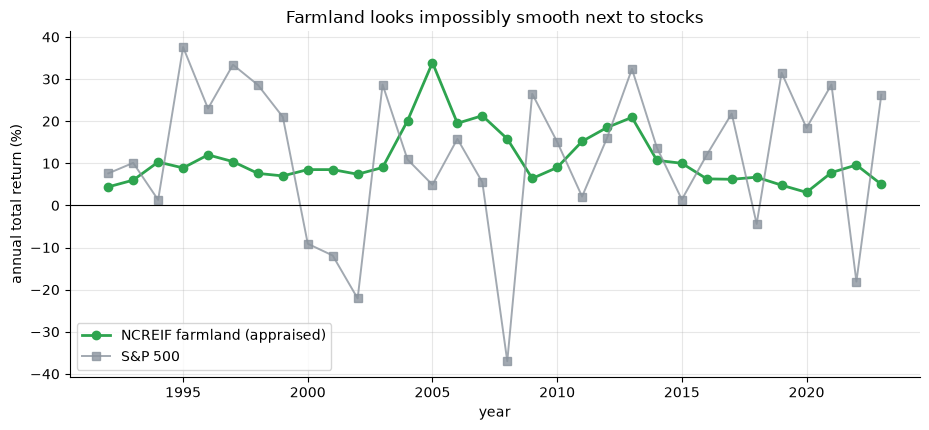

farmland vol: 6.6%   S&P vol: 17.7%


In [2]:
yrs = ANN.index.values
fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.plot(yrs, ANN['farmland']*100, 'o-', c=GREEN, lw=2, label='NCREIF farmland (appraised)')
ax.plot(yrs, ANN['spx']*100, 's-', c=GREY, lw=1.4, alpha=.8, label='S&P 500')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('annual total return (%)'); ax.set_xlabel('year')
ax.set_title('Farmland looks impossibly smooth next to stocks'); ax.legend()
plt.tight_layout(); plt.show()
print(f"farmland vol: {ANN['farmland'].std()*100:.1f}%   S&P vol: {ANN['spx'].std()*100:.1f}%")

Farmland's annual swings are tiny (**6.6%** vol) next to the S&P's (**17.7%**), and the two barely move together (correlation **-0.13**). Case closed? Not quite — because *who decides farmland's price each year?* A surveyor, not a market.

**The catch: appraisal smoothing.** Nobody trades a cornfield every day, so its "return" is an appraiser's opinion that only nudges toward reality each year. That **moving-average** effect mechanically shrinks the ups and downs. The tell is *autocorrelation*: a real tradable asset's good and bad years are roughly random, but the appraisal index's years are strongly linked to the year before. Reverse the smoothing and the hidden volatility reappears:

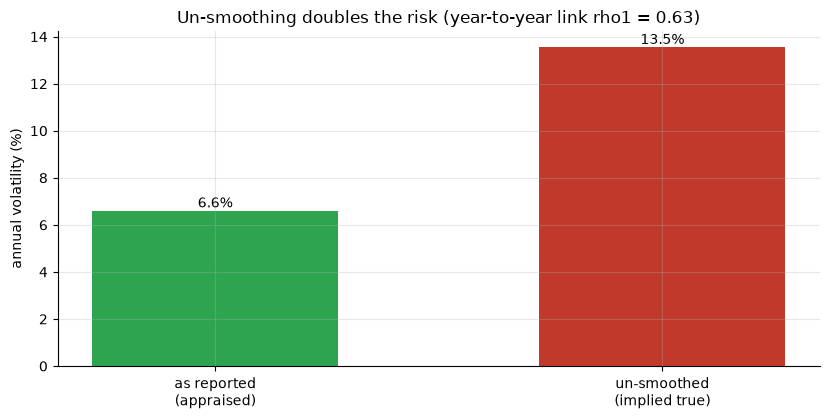

reported vol 6.6%  ->  un-smoothed 13.5%  (the survey hid ~51%)


In [3]:
rep = ANN['farmland'].values
rho1 = st.autocorr(rep, 1)
sm = st.smoothing_summary(rep)
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(['as reported\n(appraised)', 'un-smoothed\n(implied true)'],
       [sm['vol_reported']*100, sm['vol_unsmoothed']*100], color=[GREEN, RED], width=.55)
for i,v in enumerate([sm['vol_reported']*100, sm['vol_unsmoothed']*100]):
    ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
ax.set_ylabel('annual volatility (%)')
ax.set_title(f'Un-smoothing doubles the risk (year-to-year link rho1 = {rho1:.2f})')
plt.tight_layout(); plt.show()
print(f'reported vol {sm["vol_reported"]*100:.1f}%  ->  un-smoothed {sm["vol_unsmoothed"]*100:.1f}%  (the survey hid ~{(1-sm["vol_ratio"])*100:.0f}%)')

The reported 6.6% volatility is really more like **13.5%** once you undo the appraisal lag — the smoothness is paint, not steel. **And the only farmland you can buy proves it.** Here is what the tradable REITs actually did:

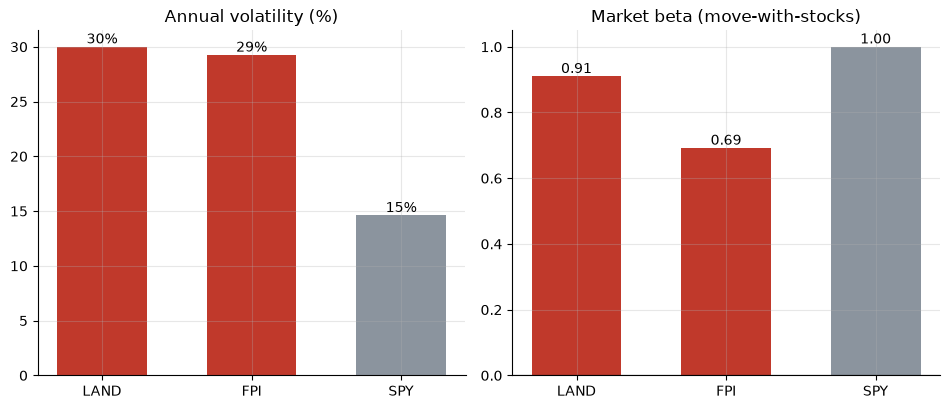

tradable farmland: ~30% vol, beta ~0.7-0.9 — the opposite of calm & uncorrelated


In [4]:
if HAVE_REAL:
    rets = REAL['returns']
    vols = [rets[c].std()*np.sqrt(12)*100 for c in ['LAND','FPI','SPY']]
    betas = [st.market_beta(rets['LAND'], rets['SPY'])['beta'],
             st.market_beta(rets['FPI'],  rets['SPY'])['beta'], 1.0]
else:
    vols  = [R['land_vol'], R['fpi_vol'], R['spy_vol']]
    betas = [R['land_beta'], R['fpi_beta'], 1.0]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.6, 4.2))
labs = ['LAND', 'FPI', 'SPY']; cols = [RED, RED, GREY]
a1.bar(labs, vols, color=cols, width=.6); a1.set_title('Annual volatility (%)')
for i,v in enumerate(vols): a1.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom')
a2.bar(labs, betas, color=cols, width=.6); a2.axhline(0, c='k', lw=.8)
a2.set_title('Market beta (move-with-stocks)')
for i,v in enumerate(betas): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('tradable farmland: ~30% vol, beta ~0.7-0.9 — the opposite of calm & uncorrelated')

There it is. The buyable farmland (LAND, FPI) runs at **~30% volatility** — *double* the S&P — and moves *with* the market (beta ≈ 0.9). The serene 6.6%-vol diversifier exists only in the appraiser's spreadsheet.

## 5 · The verdict

- **Signal — Weak.** Farmland earns a real return (~8%/yr real) and leans the right way on inflation — but the inflation link isn't statistically solid (t = 0.83), and the diversification is mostly an appraisal artifact.
- **Tradability — Fragile.** You *can* buy LAND/FPI, but they're small, leveraged, ~30%-vol REITs (Sharpe ~0.2 vs the market's ~1.0) — not the smooth index.
- **Smooth & uncorrelated? — Busted.** The calm is appraisal smoothing; un-smoothed, farmland's volatility doubles and its market link reappears.

## 6 · Could you actually trade it? — what you'd really own

Suppose you're sold on farmland and buy the only retail vehicles. How does a dollar in LAND/FPI compare with a dollar in the S&P, after the bumps?

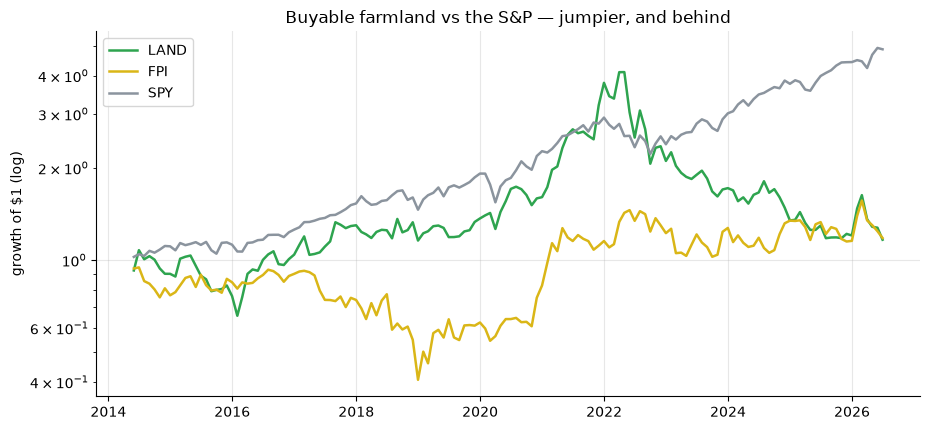

{'LAND': 1.16, 'FPI': 1.18, 'SPY': 4.87}


In [5]:
if HAVE_REAL:
    rets = REAL['common']
    growth = (1 + rets[['LAND','FPI','SPY']]).cumprod()
    fig, ax = plt.subplots(figsize=(9.4, 4.4))
    for c, col in zip(['LAND','FPI','SPY'], [GREEN, AMBER, GREY]):
        ax.plot(growth.index, growth[c], lw=1.8, label=c, c=col)
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
    ax.set_title('Buyable farmland vs the S&P — jumpier, and behind'); ax.legend()
    plt.tight_layout(); plt.show()
    print({c: round(float(growth[c].iloc[-1]),2) for c in ['LAND','FPI','SPY']})
else:
    sh = {'LAND': R['land_sh_n'], 'FPI': R['fpi_sh_n'], 'SPY': R['spy_sh']}
    fig, ax = plt.subplots(figsize=(8.6, 4.2))
    ax.bar(list(sh), list(sh.values()), color=[GREEN, AMBER, GREY], width=.6)
    for i,(k,v) in enumerate(sh.items()): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
    ax.set_ylabel('net Sharpe ratio'); ax.set_title('Risk-adjusted return: farmland REITs vs S&P')
    plt.tight_layout(); plt.show()
    print('net Sharpe — LAND %.2f  FPI %.2f  SPY %.2f' % (R['land_sh_n'], R['fpi_sh_n'], R['spy_sh']))

Over the listed era LAND/FPI returned ~5%/yr at ~30% vol — a **net Sharpe ~0.2** against the S&P's **~1.0** — while taking you on a much wilder ride. As a diversifier in a sleeve it has a place; as *the* inflation-proof calm compounder of the pitch, the tradable version doesn't deliver.

## 7 · Going further 🚪

- **The same illusion elsewhere.** Every appraisal-based private-asset index — commercial real estate, private equity, infrastructure — wears the same smooth mask. The 0.63 year-to-year link is the giveaway; un-smooth before you trust a Sharpe or a correlation.
- **The measurement-artifact cousin.** [Study 120 — Excess-CAPE-Yield](../../120-excess-cape-yield/) is the same shape: a real signal that turns into a mirage once you account for how it's measured.
- **Do it yourself.** Swap in the live NCREIF quarterly series (members-only) and re-run the un-smoothing; the doubling of volatility is robust to the exact smoothing parameter.

*Think farmland is your low-vol inflation shield? Plot the un-smoothed series next to your REIT holding's drawdowns — and decide whether you're buying the asset or the appraisal.*